In [1]:
%load_ext autoreload
%autoreload 2
%aimport fac_graphs

In [2]:
import jax
from jax import numpy as jnp
from energax.sampling import sampler
from energax.sampling.continuous import LangevinSampler
import equinox as eqx
from fac_graphs.graph_utils import draw_graph
from fac_graphs.inference.gibbs_sampling import GibbsSampler
import optax


from fac_graphs.models.factor_graphs import FactorGraph, VariableNode, FactorNode
from energax.ebms.ebm import FunctionalEBM
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

key = jax.random.PRNGKey(0)

## Create Data Set

Create a 3D multivariate Gaussian as our dataset with a 1000 samples.

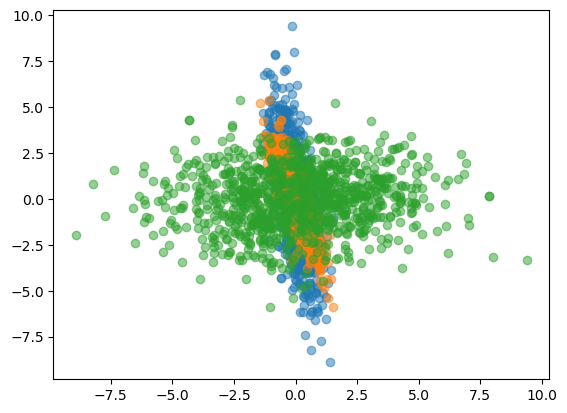

In [3]:
nr_modes = 3
key = jax.random.PRNGKey(3)
A = jax.random.normal(key, (nr_modes, nr_modes))
Cov = jnp.dot(A, A.T)
data = jax.random.multivariate_normal(key, jnp.zeros(nr_modes), Cov, (1000,))

plt.scatter(data[:, 0], data[:, 1], alpha=0.5)
plt.scatter(data[:, 0], data[:, 2], alpha=0.5)
plt.scatter(data[:, 1], data[:, 2], alpha=0.5)

## Set up factor graph

Create a factor graph with Gaussian priors and quadratic couplings.

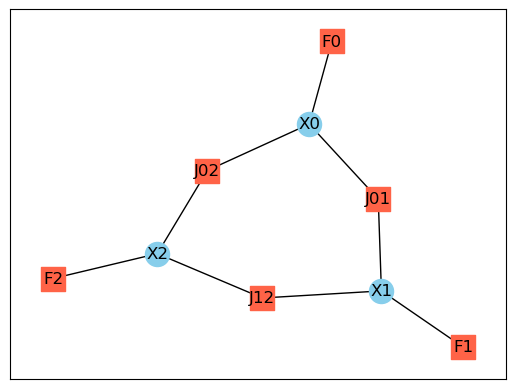

In [4]:
def gaussian_potential(W, inputs, epsilon=1e-6):
    mean, var = W
    return 0.5 * jnp.sum((inputs["phi"] - mean) ** 2 / (jnp.abs(var) + epsilon))


def coupling_potential(W, inputs, epsilon=1e-6):
    return 0.5 * jnp.sum(W * (inputs["x1"] - inputs["x2"]) ** 2)


variables = [VariableNode(name=f"X{i}") for i in range(nr_modes)]
factor_list = []

for i in range(nr_modes):
    W = (jnp.array([0.5 + i * 0.5]), jnp.array([2.0]))
    gaussian_ebm = FunctionalEBM(
        lambda W, dict_in: gaussian_potential(W, dict_in),
        params=W,
    )

    gaussian_factor = FactorNode(
        connected_variables=[variables[i]],
        factor=gaussian_ebm,
        name=f"F{i}",
        array_inputs=False,
        mapping={variables[i]: "phi"},
    )
    factor_list.append(gaussian_factor)

for i in range(nr_modes):
    for j in range(i + 1, nr_modes):
        w = jnp.array([0.0])
        coupling_ebm = FunctionalEBM(
            lambda W, dict_in: coupling_potential(W, dict_in),
            params=w,
        )
        coupling_factor = FactorNode(
            connected_variables=[variables[i], variables[j]],
            factor=coupling_ebm,
            name=f"J{i}{j}",
            array_inputs=False,
            mapping={variables[i]: "x1", variables[j]: "x2"},
        )
        factor_list.append(coupling_factor)

factor_graph = FactorGraph(factor_list)
draw_graph(factor_graph)

## Set up the Gibbs sampler

To set up the Gibbs sampler we have to define all the local samplers.

In [5]:
steps = 4000
n_chains = 100
sample_fn = lambda x: LangevinSampler(
    x, n_chains, -1.0, 1.0, 0.01, jnp.sqrt(2 * 0.01), int(steps)
)
var_dims = 1

samps = {var: sample_fn(var_dims) for var in factor_graph.variables}
num_chains = 1
gibbs_repetitions = 1

gibbs_sampler = GibbsSampler(
    samps,
    num_chains=num_chains,
    reps=gibbs_repetitions,
    is_evidence={var: False for var in factor_graph.variables},
    squeeze=False,
)

vals = {var: jnp.zeros((var_dims,)) for var in factor_graph.variables}

gibbs_sampler.sample_single_variable(factor_graph, variables[0], vals, key)

Array([2.757458], dtype=float32)

Run the Gibbs sampler to test it.

In [6]:
gibbs_sampler.run_chain(factor_graph, vals, key)

{VariableNode(name='X0'): Array([0.81611824], dtype=float32),
 VariableNode(name='X1'): Array([-0.38063413], dtype=float32),
 VariableNode(name='X2'): Array([1.2869521], dtype=float32)}

Vmap over the Gibbs sampler

In [7]:
sampler_jit = eqx.filter_jit(
    eqx.filter_vmap(gibbs_sampler.run_chain, in_axes=(None, 0, 0, None))
)
batch_size = 100
keys = jax.random.split(key, (batch_size,))
vals = {
    var: jax.random.normal(key, shape=(batch_size, var_dims))
    for i, var in enumerate(factor_graph.variables)
}
gibbs_samples = sampler_jit(
    factor_graph, vals, keys, is_evidence={var: False for var in factor_graph.variables}
)

## Define a function to sample the joint distribution from the factor graph

In [8]:
@eqx.filter_jit
def sample_joint_distribution(key, factor_graph, batch_size=10):
    keys1 = jax.random.split(key, len(factor_graph.variables))
    keys2 = jax.random.split(key, (batch_size,))
    vals = {
        var: jax.random.normal(keys1[i], shape=(batch_size, 1))
        for i, var in enumerate(factor_graph.variables)
    }
    samples = sampler_jit(
        factor_graph,
        vals,
        keys2,
        is_evidence={var: False for var in factor_graph.variables},
    )
    return samples


out = sample_joint_distribution(key, factor_graph, batch_size=100)
out[variables[1]].mean()

Array(0.862507, dtype=float32)

## Define the CD loss

the CD loss for a fully visible model:

$$
\mathbb{E}_{\mathbf{v} \sim p_{\text{data}}}[\log p(\mathbf{v})] - \mathbb{E}_{\mathbf{v} \sim p_{\text{model}}}[\log p(\mathbf{v})]
$$

In [9]:
def loss_fct(fg, samples, data_sample, regularization=0.0):
    energy_plus = jnp.array(0.0)
    energy_minus = jnp.array(0.0)
    for factor in fg.factors:
        connected_vars = factor.connected_variables
        mapping = factor.mapping
        sample_vals = {mapping[var]: samples[var] for var in connected_vars}
        data_vals = {mapping[var]: data_sample[var] for var in connected_vars}
        energy_plus += eqx.filter_vmap(factor.factor.energy_function)(data_vals)
        energy_minus += eqx.filter_vmap(factor.factor.energy_function)(sample_vals)
    return (
        energy_plus.mean()
        - energy_minus.mean()
        + regularization * (energy_plus.mean() ** 2 + energy_minus.mean() ** 2)
    )

In [10]:
data_batch = {variables[i]: data[i, :20] for i in range(nr_modes)}
loss_fct(factor_graph, out, data_batch, regularization=0.0)

Array(1.456134, dtype=float32)

## Set up the optimizer and the optimization step

In [11]:
optimizer = optax.adam(learning_rate=0.01)
opt_state = optimizer.init(eqx.filter(factor_graph, eqx.is_array))

In [12]:
@eqx.filter_jit
def step(fg, samples, data, opt_state):
    value, grads = eqx.filter_jit(eqx.filter_value_and_grad(loss_fct))(
        fg, samples, data, regularization=0.0
    )
    updates, opt_state = optimizer.update(grads, opt_state, fg)
    fg = eqx.apply_updates(fg, updates)
    return fg, opt_state, value

## Run optimization

In [13]:
batch_size = 100
nepochs = 100
nbatchs = len(data) // batch_size
loss_track = []
mean_track = []
std_track = []

for epoch in tqdm(range(nepochs)):
    key, subkey = jax.random.split(key)
    loss_model = 0.0
    acc_train = 0.0
    for j in range(nbatchs):
        key, subkey = jax.random.split(key)
        sample_batch = sample_joint_distribution(
            key, factor_graph, batch_size=batch_size
        )
        mean_track.append(sample_batch[variables[0]].mean())
        std_track.append(sample_batch[variables[0]].std())
        key, subkey = jax.random.split(key)
        idx = jax.random.choice(
            subkey, jnp.arange(len(data)), shape=(batch_size,), replace=False
        )
        data_batch = {variables[i]: data[idx, i] for i in range(nr_modes)}

        factor_graph, opt_state, value_loss = step(
            factor_graph, sample_batch, data_batch, opt_state
        )

        loss_model += value_loss

    loss_model /= nbatchs
    acc_train /= nbatchs
    loss_track.append(loss_model)

  0%|          | 0/100 [00:00<?, ?it/s]

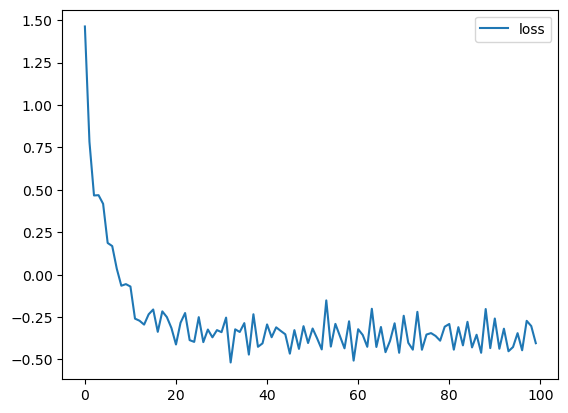

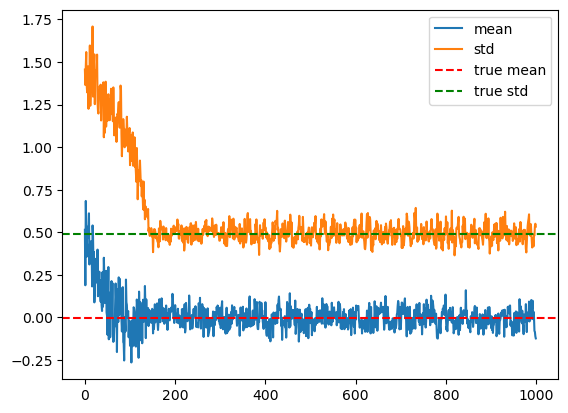

In [14]:
plt.plot(loss_track, label="loss")
plt.legend()
plt.show()

plt.plot(mean_track, label="mean")
plt.plot(std_track, label="std")
plt.axhline(data[:, 0].mean(), color="red", linestyle="--", label="true mean")
plt.axhline(data[:, 0].std(), color="green", linestyle="--", label="true std")
plt.legend()
plt.show()

## Compare model samples to data

In [15]:
sample_batch = sample_joint_distribution(key, factor_graph, batch_size=1000)

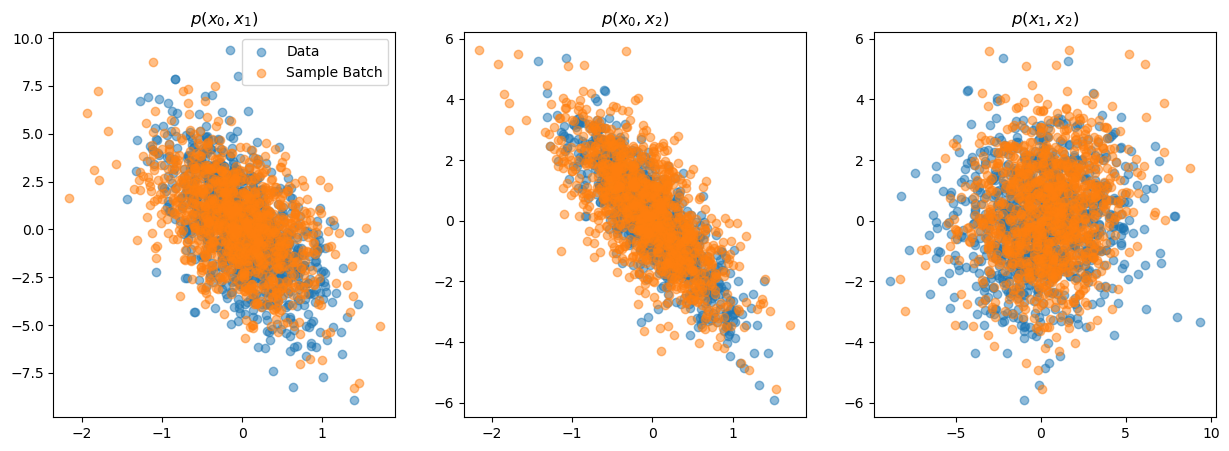

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# First subplot
scatter1 = axs[0].scatter(data[:, 0], data[:, 1], alpha=0.5, label="Data")
scatter2 = axs[0].scatter(
    sample_batch[variables[0]],
    sample_batch[variables[1]],
    alpha=0.5,
    label="Sample Batch",
)
axs[0].set_title(r"$p(x_0, x_1)$")

# Second subplot
axs[1].scatter(data[:, 0], data[:, 2], alpha=0.5)
axs[1].scatter(sample_batch[variables[0]], sample_batch[variables[2]], alpha=0.5)
axs[1].set_title(r"$p(x_0, x_2)$")

# Third subplot
axs[2].scatter(data[:, 1], data[:, 2], alpha=0.5)
axs[2].scatter(sample_batch[variables[1]], sample_batch[variables[2]], alpha=0.5)
axs[2].set_title(r"$p(x_1, x_2)$")

# Add legend to the first subplot
axs[0].legend(loc="upper right")